In [1]:
import pandas as pd
import numpy as np
customers = pd.read_csv('customer_hm.csv')
transactions = pd.read_csv('transactions_hm.csv')
articles = pd.read_csv('articles_hm.csv')

In [2]:
print(articles.info())
print(transactions.info())
print(customers.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id    105542 non-null  int64 
 13 

In [3]:
# 판매 채널 (1 : 오프라인, 2: 온라인) 이므로 'sales_channel_id' 범주형 변수로 변환
transactions['sales_channel_id'] = transactions['sales_channel_id'].astype('category')

# 문자열로 되어 있는 날짜를 실제 날짜/시간 타입(datetime)으로 변환
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions['year'] = transactions['t_dat'].dt.year
transactions['month'] = transactions['t_dat'].dt.month

# 극단치 제거 ('price','age')
transactions = transactions[transactions['price'] > 0].copy()   # 0원 제거
upper_cap = transactions['price'].quantile(0.99)
transactions['price'] = transactions['price'].clip(upper=upper_cap)    # 상위 1%보다 큰 price는 상위 1% price로 대체
transactions['log_price'] = np.log1p(transactions['price'])    # 로그 변환으로 극단치 영향 완화
print(transactions[['price', 'log_price']].describe())

customers = customers[(customers['age'] >= 5) & (customers['age'] <= 95)]


              price     log_price
count  1.048575e+06  1.048575e+06
mean   2.749282e-02  2.697873e-02
std    1.751963e-02  1.683893e-02
min    2.372880e-04  2.372599e-04
25%    1.523729e-02  1.512237e-02
50%    2.540678e-02  2.508939e-02
75%    3.388136e-02  3.332003e-02
max    1.016780e-01  9.683444e-02


In [4]:
# 각 테이블 결측치 개수 확인
print(customers.isna().sum())
print(transactions.isna().sum())
print(articles.isna().sum())

customer_id               0
FN                        0
Active                    0
club_member_status        0
fashion_news_frequency    1
age                       0
dtype: int64
t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
year                0
month               0
log_price           0
dtype: int64
article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name        

In [10]:
# transactions과 articles 테이블을 'article id' 기준으로 병합
tranart=transactions.merge(articles, on='article_id', how='inner')
print(tranart.info)

<bound method DataFrame.info of              t_dat                                        customer_id  \
0       2019-11-05  3e2b60b679e62fb49516105b975560082922011dd752ec...   
1       2019-05-22  89647ac2274f54c770aaa4b326e0eea09610c252381f37...   
2       2019-05-10  2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...   
3       2019-08-26  7b3205de4ca17a339624eb5e3086698e9984eba6b47c56...   
4       2019-08-10  3b77905de8b32045f08cedb79200cdfa477e9562429a39...   
...            ...                                                ...   
1048570 2019-03-25  8e900818a1da0e73300a012794615993fbefb43f851430...   
1048571 2019-10-18  13aa106eeb8a6fa2f9e2ab888a3a2ee118a3900670f0d8...   
1048572 2019-04-06  5f51e21397c1248aafdf9712435bd4be063eb093f56229...   
1048573 2019-03-20  3421bd479ee13287a65660cf816b01d0d803d1d6d0fe73...   
1048574 2019-01-13  5813663221b265eba9e4604e482be951d9a97ae022a88a...   

         article_id     price sales_channel_id  year  month  log_price  \
0         6983280

In [9]:
# product_group_name 기준 매출 집계 및 매출 비중 계산
group_sales = tranart.groupby('product_group_name')['price'].sum().sort_values(ascending=False)
group_salespercent = group_sales / group_sales.sum() * 100
group5 = group_salespercent.head(5)
print(group_sales)
print(group5)
group5_sum = group5.sum()
print(f"Top 5 제품군 매출 비중 합계: {group5_sum:.2f}%")

product_group_name
Garment Upper body       10898.805660
Garment Lower body        7550.420295
Garment Full body         4294.764199
Swimwear                  2034.305908
Underwear                 1674.650790
Shoes                      983.026185
Accessories                823.723169
Nightwear                  279.762983
Socks & Tights             243.473068
Unknown                     35.726712
Bags                         7.478695
Items                        1.302000
Underwear/nightwear          0.443102
Furniture                    0.203220
Cosmetic                     0.141068
Garment and Shoe care        0.045441
Interior textile             0.008119
Name: price, dtype: float64
product_group_name
Garment Upper body    37.805951
Garment Lower body    26.191018
Garment Full body     14.897747
Swimwear               7.056633
Underwear              5.809055
Name: price, dtype: float64
Top 5 제품군 매출 비중 합계: 91.76%


In [63]:
# TOP5 제품군만 나타낸 tranart 테이블
top5_groups = group5.index.tolist() 
top5 = tranart[tranart['product_group_name'].isin(top5_groups)]
print(top5)

             t_dat                                        customer_id  \
0       2019-11-05  3e2b60b679e62fb49516105b975560082922011dd752ec...   
1       2019-05-22  89647ac2274f54c770aaa4b326e0eea09610c252381f37...   
2       2019-05-10  2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...   
5       2019-01-12  ef00c5c37b6edec253e58ba7be07aecc431742332bfc4b...   
6       2019-03-22  437d51082dc72fe41289783e165a2a2a6958ec7bd980b4...   
...            ...                                                ...   
1048570 2019-03-25  8e900818a1da0e73300a012794615993fbefb43f851430...   
1048571 2019-10-18  13aa106eeb8a6fa2f9e2ab888a3a2ee118a3900670f0d8...   
1048572 2019-04-06  5f51e21397c1248aafdf9712435bd4be063eb093f56229...   
1048573 2019-03-20  3421bd479ee13287a65660cf816b01d0d803d1d6d0fe73...   
1048574 2019-01-13  5813663221b265eba9e4604e482be951d9a97ae022a88a...   

         article_id     price sales_channel_id  year  month  log_price  \
0         698328010  0.016932                2  2

In [64]:
# 매출액 TOP5의 매달 매출 순위
month_sales = top5.groupby(['month', 'product_group_name'])['price'].sum().reset_index()
month_sales_sorted = month_sales.sort_values(['month', 'price'], ascending=[True, False]).reset_index(drop=True)
month_sales_sorted = month_sales_sorted.rename(columns={'price': 'monthly_sales'})
print(month_sales_sorted)

    month  product_group_name  monthly_sales
0       1  Garment Upper body     921.020693
1       1  Garment Lower body     556.353626
2       1   Garment Full body     180.670881
3       1           Underwear     146.649135
4       1            Swimwear     126.410880
5       2  Garment Upper body     816.064236
6       2  Garment Lower body     562.590525
7       2   Garment Full body     207.721017
8       2           Underwear     123.556864
9       2            Swimwear     118.920830
10      3  Garment Upper body     891.927473
11      3  Garment Lower body     659.518338
12      3   Garment Full body     324.649457
13      3            Swimwear     184.669745
14      3           Underwear     128.932016
15      4  Garment Upper body     834.136795
16      4  Garment Lower body     741.812796
17      4   Garment Full body     512.977254
18      4            Swimwear     275.359050
19      4           Underwear     130.957152
20      5  Garment Upper body     793.796201
21      5 

In [65]:
# 월별 전체 매출 계산
month_total = tranart.groupby('month')['price'].sum().reset_index().rename(columns={'price':'total_sales'})

# TOP5 매출과 JOIN
month_sales_merged = month_sales_sorted.merge(month_total, on='month')

# 월별 TOP5 제품군들이 전체 매출에서 차지하는 비중
month_sales_merged['pct'] = month_sales_merged['monthly_sales'] / month_sales_merged['total_sales'] * 100

print(month_sales_merged)

    month  product_group_name  monthly_sales  total_sales        pct
0       1  Garment Upper body     921.020693  2130.683741  43.226532
1       1  Garment Lower body     556.353626  2130.683741  26.111507
2       1   Garment Full body     180.670881  2130.683741   8.479479
3       1           Underwear     146.649135  2130.683741   6.882727
4       1            Swimwear     126.410880  2130.683741   5.932879
5       2  Garment Upper body     816.064236  1995.242302  40.900508
6       2  Garment Lower body     562.590525  1995.242302  28.196602
7       2   Garment Full body     207.721017  1995.242302  10.410817
8       2           Underwear     123.556864  1995.242302   6.192574
9       2            Swimwear     118.920830  1995.242302   5.960220
10      3  Garment Upper body     891.927473  2377.627995  37.513332
11      3  Garment Lower body     659.518338  2377.627995  27.738500
12      3   Garment Full body     324.649457  2377.627995  13.654342
13      3            Swimwear     

In [66]:
### 제품군별 피크인 달
peak_month = (
    month_sales_merged
    .loc[month_sales_merged.groupby('product_group_name')['pct'].idxmax(),
         ['product_group_name', 'month', 'pct']]
)

print("제품군별 Peak Month:")
print(peak_month)

제품군별 Peak Month:
    product_group_name  month        pct
27   Garment Full body      6  20.698576
36  Garment Lower body      8  28.583797
45  Garment Upper body     10  49.937451
28            Swimwear      6  15.246060
38           Underwear      8   7.383213


In [67]:
# TOP5 제품군의 표준편차 계산 (작을수록 변동성이 작다)
# Underwear : 기본 수요 꾸준하여 시즌 영향이 적다 => 안정적 매출원
# Garment Upper body : 변동성 가장 높다 => 이벤트성 매출원 
var = month_sales_sorted.groupby('product_group_name')['monthly_sales'].std().reset_index()
var_sorted= var.sort_values(['monthly_sales'], ascending=[False]).reset_index(drop=True)
print(var)

   product_group_name  monthly_sales
0   Garment Full body     146.088502
1  Garment Lower body     106.130276
2  Garment Upper body     184.978993
3            Swimwear     154.618050
4           Underwear      15.114396


In [ ]:
### 시각화 ###

import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 1. 설치된 폰트 확인 (예: Windows 기본 'Malgun Gothic')
font_path = "C:/Windows/Fonts/malgun.ttf"  # Windows 기본 폰트
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

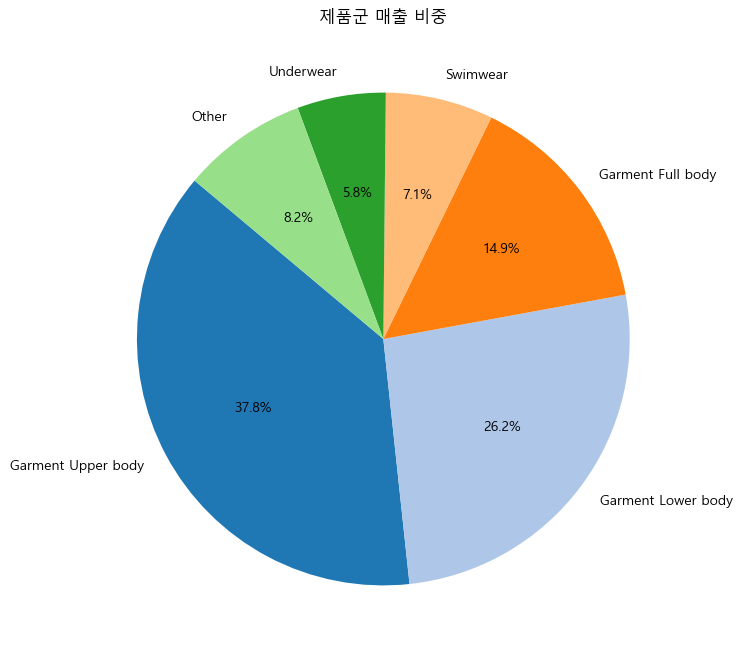

In [57]:
### TOP5 제품군 및 기타 제품군 매출 비중

import matplotlib.pyplot as plt

# 기타 제품군 비중 계산
other_percent = 100 - group5_sum

# 원형그래프 라벨 및 값 설정
labels = list(group5.index) + ['Other']
sizes = list(group5.values) + [other_percent]

# 원형 그래프 그리기
plt.figure(figsize=(8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title("제품군 매출 비중")
plt.show()

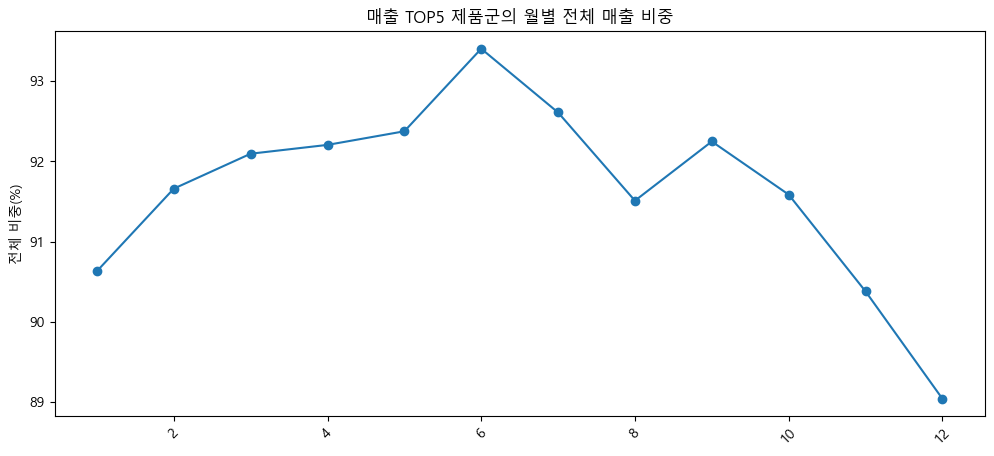

In [58]:
### 월 전체 대비 TOP5 합계 비중 (“이 달은 TOP5 제품군이 전체 매출에서 얼마나 영향력이 있었는가?”)

top5_total_share = month_sales_merged.groupby('month')['pct'].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(top5_total_share['month'], top5_total_share['pct'], marker='o')
plt.xticks(rotation=45)
plt.ylabel("전체 비중(%)")
plt.title("매출 TOP5 제품군의 월별 전체 매출 비중")
plt.show()

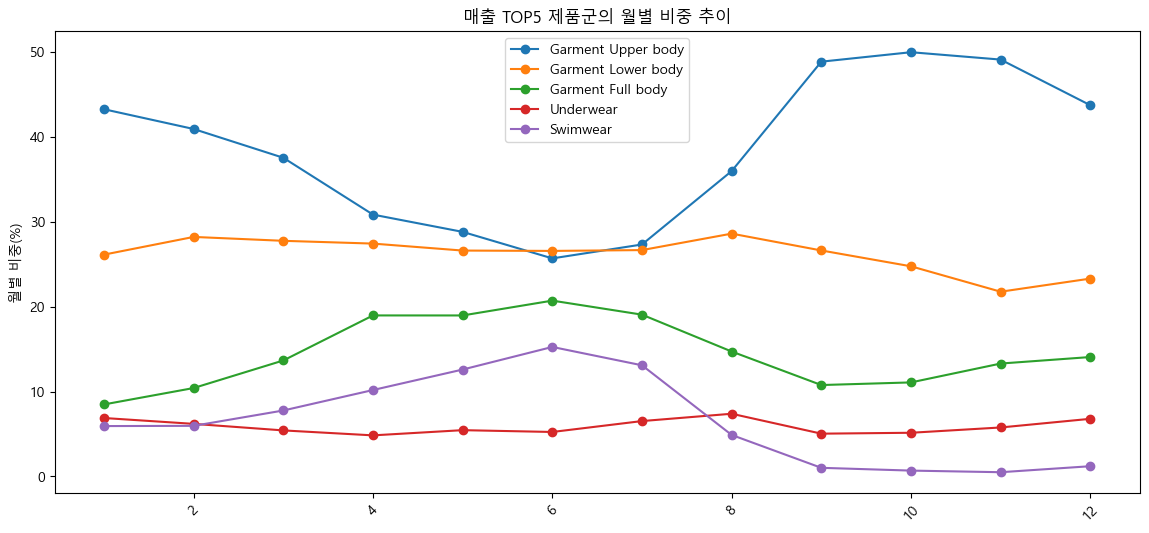

In [49]:
### 매출 TOP5 제품군별 월별 비중

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
for pg in month_sales_merged['product_group_name'].unique():
    subset = month_sales_merged[month_sales_merged['product_group_name'] == pg]
    plt.plot(subset['month'], subset['pct'], marker='o', label=pg)

plt.xticks(rotation=45)
plt.ylabel("월별 비중(%)")
plt.title("매출 TOP5 제품군의 월별 비중 추이")
plt.legend()
plt.show()


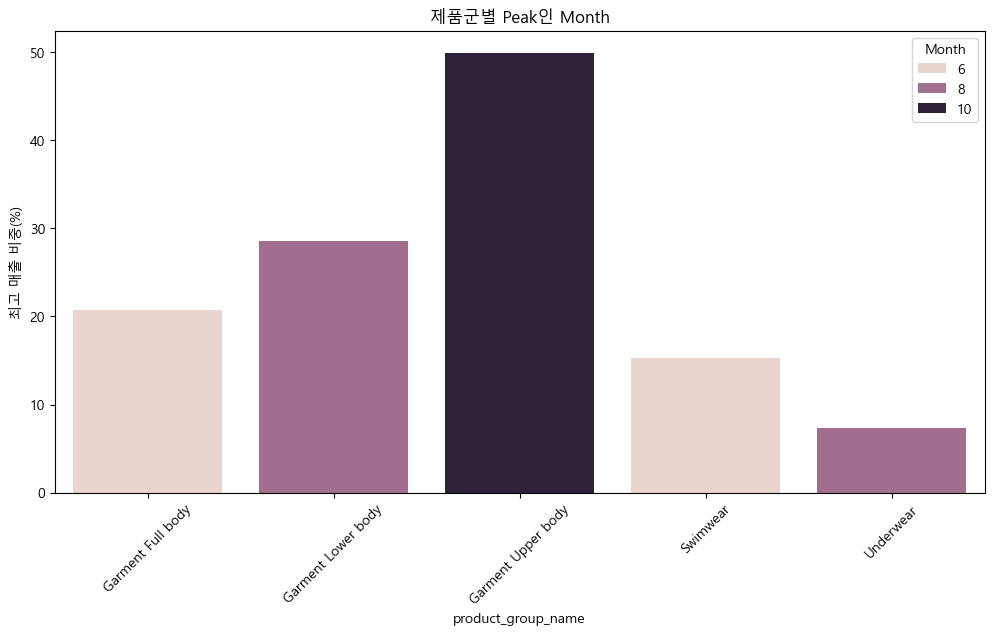

In [ ]:
### 제품군별 피크인 달

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(
    data=peak_month,
    x='product_group_name',
    y='pct',
    hue='month',
    dodge=False
)

plt.xticks(rotation=45)
plt.ylabel("최고 매출 비중(%)")
plt.title("제품군별 Peak인 Month")
plt.legend(title='Month')
plt.show()

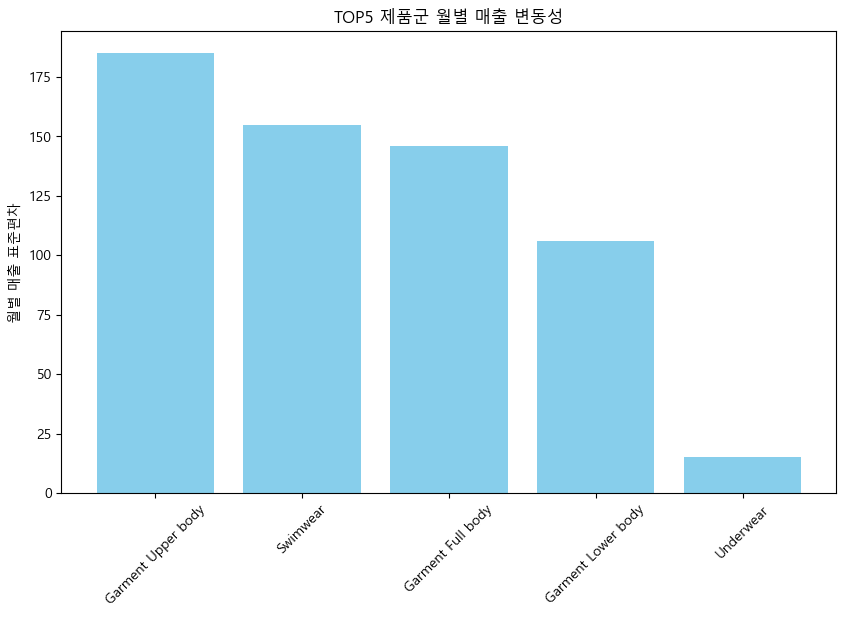

In [ ]:
### TOP5 제품군 월별 매출 변동성 (표준편차)
### 표준편차가 작다 → 매출이 꾸준하고 안정적
### 표준편차가 크다 → 매출 변동이 심하고 이벤트/시즌 영향이 큰 제품군

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(var_sorted['product_group_name'], var_sorted['monthly_sales'], color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("월별 매출 표준편차")
plt.title("TOP5 제품군 월별 매출 변동성")
plt.show()